In [136]:
import numpy as np
import matplotlib.pyplot as plt
import time
# import copy
# import seaborn as sns


def tic():
    return time.time()


def toc(start_time):
    elapsed_time = time.time() - start_time
    print(f"Elapsed time: {elapsed_time} seconds")




In [137]:
class GarnetEnv:
    """
    GARNET (Generalized Action and Reward Network) Environment.
    A randomly generated finite MDP with a strict branching factor.
    Optimized for cost minimization.
    """
    def __init__(self, n_states=100, n_actions=40, branching_factor=10, gamma=0.99, seed=42):
        self.n_states = n_states
        self.n_actions = n_actions
        # Branching factor cannot exceed the total number of states
        self.branching_factor = min(branching_factor, n_states)
        self.gamma = gamma
        self.rng = np.random.RandomState(seed)

        # 1. Initialize transition probabilities P(s' | s, a) with sparsity
        self.P = np.zeros((n_states, n_actions, n_states))
        for s in range(n_states):
            for a in range(n_actions):
                # Randomly pick 'branching_factor' distinct next states
                next_states = self.rng.choice(
                    n_states,
                    size=self.branching_factor,
                    replace=False
                )
                # Assign random probabilities that sum to 1 to these specific states
                probs = self.rng.dirichlet(np.ones(self.branching_factor))
                self.P[s, a, next_states] = probs

        # 2. Initialize cost function c(s, a) bounded between 0 and 1
        self.C = self.rng.rand(n_states, n_actions)

    def reset(self):
        """Returns a random starting state for simulation."""
        return self.rng.randint(self.n_states)

    def step(self, state, action):
        """Simulates a single transition and cost."""
        next_state = self.rng.choice(self.n_states, p=self.P[state, action])
        cost = self.C[state, action]
        return next_state, cost

    def policy_evaluation(self, pi):
        """
        Calculates exact V and Q using dynamic programming.
        Useful for exact baseline comparisons.
        """
        P_pi = np.einsum('sa,sap->sp', pi, self.P)
        C_pi = np.einsum('sa,sa->s', pi, self.C)

        I = np.eye(self.n_states)
        V = np.linalg.solve(I - self.gamma * P_pi, C_pi)
        Q = self.C + self.gamma * np.einsum('sap,p->sa', self.P, V)

        return V, Q

def simulate_and_estimate_advantages(env, pi, V_table, n_episodes=50, max_steps=50):
    """
    Simulates rollouts and computes advantage estimates.
    Returns estimated Q(s,a) and V(s) based on the rollouts.
    """
    n, m = env.n_states, env.n_actions
    returns_sa = {s: {a: [] for a in range(m)} for s in range(n)}
    returns_s = {s: [] for s in range(n)}

    total_cost = 0
    total_steps = 0

    for _ in range(n_episodes):
        state = env.reset()
        trajectory = []
        for _ in range(max_steps):
            pi[state] = pi[state]/sum(pi[state])
            action = env.rng.choice(m, p=pi[state])
            next_state, cost = env.step(state, action)
            trajectory.append((state, action, cost))
            state = next_state

        # Calculate returns
        G = 0
        for t in reversed(range(len(trajectory))):
            s, a, c = trajectory[t]
            G = c + env.gamma * G
            returns_sa[s][a].append(G)
            returns_s[s].append(G)
            total_cost += c
            total_steps += 1

    # Estimate Q and V empirically
    Q_est = np.zeros((n, m))
    V_est = np.zeros(n)

    for s in range(n):
        if returns_s[s]:
            V_est[s] = np.mean(returns_s[s])
        else:
            V_est[s] = V_table[s] # fallback to previous

        for a in range(m):
            if returns_sa[s][a]:
                Q_est[s, a] = np.mean(returns_sa[s][a])
            else:
                # Fallback to C + gamma * expected V
                Q_est[s, a] = env.C[s, a] + env.gamma * np.dot(env.P[s, a], V_est)

    A_est = Q_est - V_est[:, np.newaxis]
    avg_cost_per_step = total_cost / total_steps if total_steps > 0 else 0

    return A_est, V_est, np.mean(V_est) # avg_cost_per_step


def clip_A(A,ratio):
    epsilon = 0.2
    clipped = np.logical_or(
                np.logical_and(ratio > 1 + epsilon, A < 0),
                np.logical_and(ratio < 1 - epsilon, A > 0)
            )

            # Zero out gradients for clipped actions
    A_mod = A.copy()
    A_mod[clipped] = 0.0
    return A_mod

def plot_policy(policy_matrix, title):
    plt.figure(figsize=(8, 6))

    # annot=True puts the numbers inside the boxes
    # cmap='Blues' is a great color map for probabilities (0 to 1)
    # fmt='.2f' ensures the numbers are formatted to 2 decimal places
    sns.heatmap(policy_matrix, annot=True, cmap='Blues', fmt='.2f',
                vmin=-1, vmax=1) # vmin/vmax lock the color scale from 0 to 1

    # 4. Add formatting
    plt.title(title, fontsize=18)
    plt.xlabel('Actions ($a$)', fontsize=18)
    plt.ylabel('States ($s$)', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14, rotation=0) # Keep state labels horizontal

    plt.tight_layout()
    plt.show()


def compare_mm_rkhs_algorithm(env, iterations=50, eta=1.0, n_episodes=50, max_steps=50):
    n, m = env.n_states, env.n_actions
    pi = np.ones((n, m)) / m
    X = np.random.rand(m, m)
    R = 0.01*np.dot(X, X.T) + np.eye(m)
    beta = np.max(env.C) / (1 - env.gamma)

    history_cost = []
    history_V = []
    V_table = np.zeros(n)

    pi_mm = np.zeros((iterations,n, m))
    pi_sim_mm = np.zeros((iterations,n, m))
    A_mm = np.zeros((iterations,n, m))
    A_sim_mm = np.zeros((iterations,n, m))

    for k in range(iterations):
        if k==0:
            pi = np.ones((n, m)) / m
        else:
            pi = pi_mm[k-1]

        V, Q = env.policy_evaluation(pi)
        history_V.append(np.mean(V))

        A = Q - V[:, np.newaxis]
        new_pi = np.zeros_like(pi)
        eta_0 = eta*np.sqrt(k+1)**2
        for s in range(n):
            beta = np.max(-A[s,:])/np.sqrt(k+1)
            for a in range(m):
                R_a = R[:, a]
                R_a_T_pi = np.dot(R_a, pi[s])
                exponent = -eta_0 * (A[s, a] - beta * R_a_T_pi)
                new_pi[s, a] = pi[s, a] * np.clip(np.exp(exponent), 0.9, 1.1)
                # if a>=0 and a<=1 and s==8 and k>=iterations-10:
                #     print(k, s, a)
                #     print(exponent)
                #     print(A[s, a], beta*R_a_T_pi)
                #     print("\n")
                    
            new_pi[s] /= np.sum(new_pi[s])
        pi = new_pi
        pi_mm[k] = copy.copy(pi)
        A_mm[k] = copy.copy(A)

        if k==0:
            pi = np.ones((n, m)) / m
        else:
            pi = pi_sim_mm[k-1]

        A, V_table, avg_cost = simulate_and_estimate_advantages(env, pi, V_table, \
                                                                n_episodes, max_steps)
        history_cost.append(avg_cost-np.mean(V))


        eta_0 = eta*(np.sqrt(k+1))**2
        new_pi = np.zeros_like(pi)
        ratio = np.zeros_like(pi)
        for s in range(n):
            beta = np.max(-A[s,:])/(k+1) 
            for a in range(m):
                R_a = R[:, a]
                R_a_T_pi = np.dot(R_a, pi[s])
                
                exponent = - eta_0 * (A[s, a]- beta * R_a_T_pi)
                # Cap exponent to avoid overflow
                exponent = np.clip(exponent, -50, 50)
                # if a >=0 and a<=1 and s==8 and k>=iterations-10:
                #     print(k, s, a)
                #     print(exponent)
                #     print(A[s, a], beta*R_a_T_pi)
                #     print("\n")
                new_pi[s, a] = pi[s, a] * np.exp(exponent)
                ratio[s, a] = np.exp(exponent)

            new_pi[s] /= (np.sum(new_pi[s]) + 1e-8)
        f = 0.95*(k+1)/iterations
        f=0.95/(k+1)
        pi = f* new_pi + (1-f)*pi
        pi_sim_mm[k] = copy.copy(pi)
        A_sim_mm[k] = copy.copy(A)
        plot_policy(ratio, "Ratio" + str(k))
        plot_policy(pi_sim_mm[k]-pi_mm[k], "Delta pi_mm" + str(k))
        plot_policy(A_sim_mm[k]-A_mm[k], "Delta A_mm"+str(k))
        print()

    return pi_sim_mm, pi_mm, A_sim_mm, A_mm, history_cost


# Initialize environment
n_states, n_actions, branching_factor, gamma = 5, 5, 2, 0.95
env = GarnetEnv(n_states, n_actions, branching_factor, gamma, 101)
iterations = 10


# Run Algorithms


print("Running Sim MM-RKHS...")
start_time = tic()
pi_sim_mm, pi_mm, A_sim_mm, A_mm, history_cost = compare_mm_rkhs_algorithm(\
    env, iterations, eta=.15,\
    n_episodes=100, \
    max_steps=10)
end_time = toc(start_time)

print(history_cost)


In [138]:

def sim_ppo_algorithm(env, iterations=50, epsilon=0.2, lr=0.5, epochs=5, n_episodes=50, \
                      max_steps=50):
    n, m = env.n_states, env.n_actions
    logits = np.zeros((n, m))
    pi = np.ones((n, m)) / m

    history_cost = []
    V_table = np.zeros(n)

    for k in range(iterations):
        A, V_table, avg_cost = simulate_and_estimate_advantages(env, pi, V_table, \
                                                                n_episodes, max_steps)
        history_cost.append(avg_cost)

        pi_old = pi.copy()

        for _ in range(epochs):
            pi_current = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
            ratio = pi_current / (pi_old + 1e-8)

            clipped = np.logical_or(
                np.logical_and(ratio > 1 + epsilon, A < 0),
                np.logical_and(ratio < 1 - epsilon, A > 0)
            )

            A_mod = A.copy()
            A_mod[clipped] = 0.0

            expected_A_mod = np.sum(pi_current * A_mod, axis=1, keepdims=True)
            grad = pi_current * (A_mod - expected_A_mod)

            logits -= lr * grad

        pi = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)

    return pi, history_cost

def tabular_ppo_algorithm(env, iterations=50, epsilon=0.2, lr=0.5, epochs=5):
    """
    Section 6.1: Proximal Policy Optimization (PPO).
    Uses gradient descent on the clipped surrogate objective for cost minimization.
    """
    n, m = env.n_states, env.n_actions
    logits = np.zeros((n, m))
    pi = np.ones((n, m)) / m
    history_V = []

    for k in range(iterations):
        V, Q = env.policy_evaluation(pi)
        history_V.append(np.mean(V))

        # Advantage for cost minimization (negative is better)
        A = Q - V[:, np.newaxis]
        pi_old = pi.copy()
        # print(k, A[18,6], A[18,7])
        # Inner optimization loop (epochs)
        for _ in range(epochs):
            # Compute current policy from logits
            pi_current = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
            ratio = pi_current / (pi_old + 1e-8)

            # Identify which actions trigger the PPO clipping condition
            # Since we minimize cost, an advantage < 0 is a "good" action.
            clipped = np.logical_or(
                np.logical_and(ratio > 1 + epsilon, A < 0),
                np.logical_and(ratio < 1 - epsilon, A > 0)
            )

            # Zero out gradients for clipped actions
            A_mod = A.copy()
            A_mod[clipped] = 0.0

            # Standard policy gradient on the valid (unclipped) advantages
            expected_A_mod = np.sum(pi_current * A_mod, axis=1, keepdims=True)
            grad = pi_current * (A_mod - expected_A_mod)

            # Descend the gradient (because we are minimizing cost)
            logits -= lr * grad

        # Update policy for the next outer iteration
        pi = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)

    return pi, history_V


In [ ]:

def mm_rkhs_algorithm(env, iterations=50, eta=1.0):
    """
    Section 6.3: MM algorithm for Finite MDPs under RKHS.
    Uses closed-form exponential updates.
    """
    n, m = env.n_states, env.n_actions
    pi = np.ones((n, m)) / m
    R = np.eye(m)

    beta = np.max(env.C) / (1 - env.gamma)
    history_V = []

    for k in range(iterations):
        V, Q = env.policy_evaluation(pi)
        history_V.append(np.mean(V))

        A = Q - V[:, np.newaxis]
        new_pi = np.zeros_like(pi)
        eta_0 = eta*np.sqrt(k+1)**2
        for s in range(n):
            beta = np.max(np.abs(A[s,:]))/np.sqrt(k+1)
            p = pi[s]
            for l in range(3):
                R_pi = np.dot(R, pi[s]-p)
                exponent = -eta_0 * (A[s, :] - beta * R_pi)
                p = p * np.exp(exponent)
                p /= (np.sum(p)+1e-10)
            new_pi[s,:] = p
            new_pi[s] /= np.sum(new_pi[s])
        pi = new_pi

    return pi, history_V

def sim_mm_rkhs_algorithm(env, iterations=50, eta=1.0, n_episodes=50, max_steps=50):
    n, m = env.n_states, env.n_actions
    pi = np.ones((n, m)) / m
    X = np.random.rand(m, m)
    R = np.eye(m)
    beta = np.max(env.C) / (1 - env.gamma)

    history_cost = []
    V_table = np.zeros(n)

    for k in range(iterations):
        A, V_table, avg_cost = simulate_and_estimate_advantages(env, pi, V_table, \
                                                                n_episodes, max_steps)
        history_cost.append(avg_cost)
        # beta = np.max(A[:,:])
        eta_0 = eta*(k+1)
        new_pi = np.zeros_like(pi)
        for s in range(n):
            beta = np.max(np.abs(A[s,:]))/np.sqrt(k+1)
            p = pi[s]
            for l in range(2):
                R_pi = np.dot(R, pi[s]-p)
                exponent = -eta_0 * (A[s, :] - beta * R_pi)
                p = p * np.exp(np.clip(exponent,-1.5,1.5))
                p /= (np.sum(p)+1e-10)
            new_pi[s,:] = p
            new_pi[s] /= np.sum(new_pi[s])
        pi = new_pi

    return pi, history_cost


# Initialize environment
n_states, n_actions, branching_factor, gamma = 20, 10, 5, 0.95
env = GarnetEnv(n_states, n_actions, branching_factor, gamma, 101)
iterations = 1000


# Run Algorithms


print("Running MM-RKHS...")
start_time = tic()
det_pi_mm, det_cost_mm = mm_rkhs_algorithm(env, iterations, eta=1.15)
end_time = toc(start_time)

print("Running Sim MM-RKHS...")
start_time = tic()
pi_mm, cost_mm = sim_mm_rkhs_algorithm(env, iterations, eta=1.15, n_episodes=5, \
                                       max_steps=100)
end_time = toc(start_time)

print("Running Sim PPO...")
start_time = tic()
pi_ppo, cost_ppo = sim_ppo_algorithm(env, iterations, epsilon=0.2, lr=0.8, \
                                     epochs=10, n_episodes=10, max_steps=100)
end_time = toc(start_time)

print("Running PPO...")
start_time = tic()
det_pi_ppo, det_cost_ppo = tabular_ppo_algorithm(env, iterations, epsilon=0.2, lr=0.8, epochs=10)
end_time = toc(start_time)


Running MM-RKHS...
Elapsed time: 0.2997419834136963 seconds
Running Sim MM-RKHS...
Elapsed time: 5.4727442264556885 seconds
Running Sim PPO...
Elapsed time: 10.227526903152466 seconds
Running PPO...
Elapsed time: 0.11327004432678223 seconds


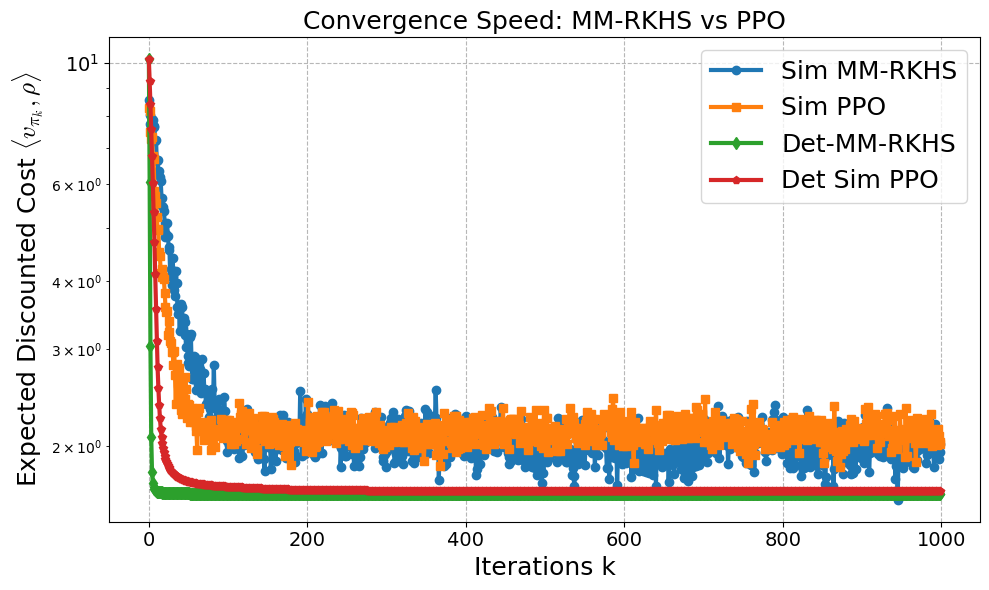

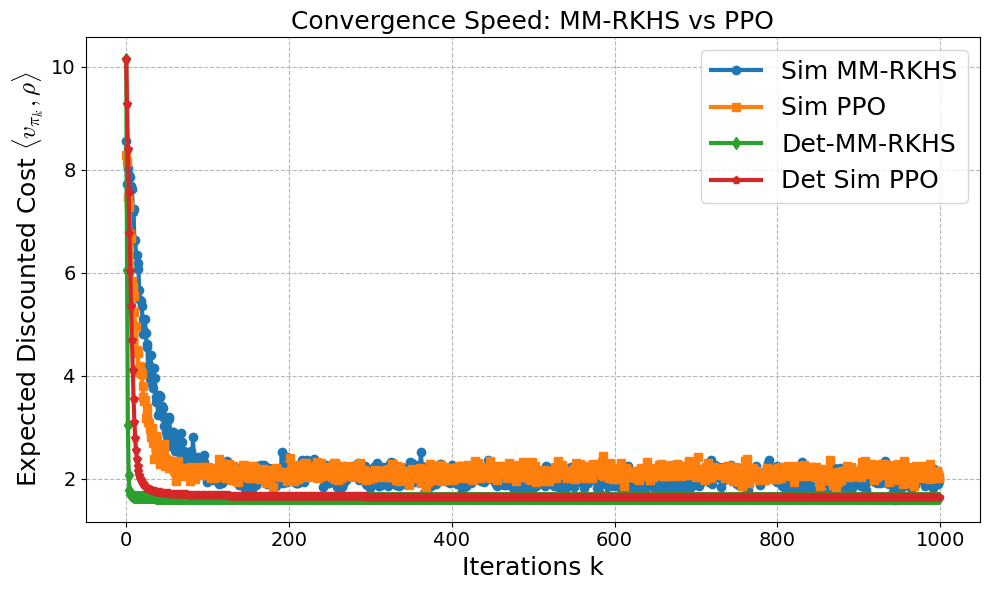

In [140]:

# Plot

plt.figure(figsize=(10, 6))
# Set font to look like LaTeX (Computer Modern)
plt.rcParams.update({
    # "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": False,  # Keep this False
    "mathtext.fontset": "cm" # 'cm' stands for Computer Modern
})


plt.plot(np.array(cost_mm), label='Sim MM-RKHS', linewidth=3, marker='o', markersize=6)
plt.plot(np.array(cost_ppo), label='Sim PPO', linewidth=3, marker='s', markersize=6)
plt.plot(det_cost_mm, label='Det-MM-RKHS', linewidth=3, marker='d', markersize=6)
plt.plot(det_cost_ppo, label='Det Sim PPO', linewidth=3, marker='p', markersize=6)

plt.yscale('log')
plt.title('Convergence Speed: MM-RKHS vs PPO', fontsize=18)
plt.xlabel('Iterations k', fontsize=18)
plt.ylabel(r'Expected Discounted Cost $\langle v_{\pi_k}, \rho\rangle$', fontsize=18)
plt.xticks(fontsize=14) # Optional: slightly smaller for tick marks to keep it clean
plt.yticks(fontsize=14)

plt.grid(True, linestyle='--', alpha=0.9)
plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('outputlog.png')
# print("Plot saved to sim_convergence.png")


# Plot

plt.figure(figsize=(10, 6))
# Set font to look like LaTeX (Computer Modern)
plt.rcParams.update({
    # "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": False,  # Keep this False
    "mathtext.fontset": "cm" # 'cm' stands for Computer Modern
})


plt.plot(np.array(cost_mm), label='Sim MM-RKHS', linewidth=3, marker='o', markersize=6)
plt.plot(np.array(cost_ppo), label='Sim PPO', linewidth=3, marker='s', markersize=6)
plt.plot(det_cost_mm, label='Det-MM-RKHS', linewidth=3, marker='d', markersize=6)
plt.plot(det_cost_ppo, label='Det Sim PPO', linewidth=3, marker='p', markersize=6)

plt.title('Convergence Speed: MM-RKHS vs PPO', fontsize=18)
plt.xlabel('Iterations k', fontsize=18)
plt.ylabel(r'Expected Discounted Cost $\langle v_{\pi_k}, \rho\rangle$', fontsize=18)
plt.xticks(fontsize=14) # Optional: slightly smaller for tick marks to keep it clean
plt.yticks(fontsize=14)

plt.grid(True, linestyle='--', alpha=0.9)
plt.legend(fontsize=18)

plt.tight_layout()
plt.savefig('output.png')
# print("Plot saved to sim_convergence.png")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_policy(policy_matrix, title):
    plt.figure(figsize=(8, 6))

    # annot=True puts the numbers inside the boxes
    # cmap='Blues' is a great color map for probabilities (0 to 1)
    # fmt='.2f' ensures the numbers are formatted to 2 decimal places
    sns.heatmap(policy_matrix, annot=True, cmap='Blues', fmt='.2f',
                vmin=-1, vmax=1) # vmin/vmax lock the color scale from 0 to 1

    # 4. Add formatting
    plt.title(title, fontsize=18)
    plt.xlabel('Actions ($a$)', fontsize=18)
    plt.ylabel('States ($s$)', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14, rotation=0) # Keep state labels horizontal

    plt.tight_layout()
    plt.show()
# plot_policy(det_pi_mm, "det_pi_mm") 
# plot_policy(pi_mm, "pi_mm_sim") 
# plot_policy(pi_ppo, "pi_ppo_sim") 

plot_policy(det_pi_ppo-det_pi_mm, "Delta pi_ppo_sim") 
plot_policy(pi_mm-det_pi_mm, "Delta pi_mm") 

